#**Actividad N1- ayuda internacional recibida por país por año desde 2004 a 2023**

**Fuente**: Our World in Data

**Formato**: CSV

**Link:** https://drive.google.com/file/d/1LIq-EpiwdmaNCnDcf5W1GWnnqC-DrXbE/view?usp=sharing

**Columnas**:
1. **ID Observación**: cada medición
2. **Código país**: identificación del país por su código
3. **País**: los países donde se realizó la medición
4. **Región mundial**: región a la que pertenecen los países sobre las cuales se realizo dicha medición.
5. **Grupo ingreso**: situación económica (bajos ingresos, medios ingresos, ingresos medio-altos o altos ingresos) a los que pertenece cada país.
6. **Año**: año en que se realizó la medición, abarcando desde el 2004 al 2023.
7. **AOD_recibida_USD_constantes_2024**:monto total de ayuda internacional recibido por un país en un año, expresado en dólares estadounidenses constantes de 2024.
8. **AOD_recibida_porcentaje_INB**: qué porcentaje representa la ayuda internacional recibida respecto del Ingreso Nacional Bruto (INB) del país.

**Cantidad de filas y columnas:** 2930 filas, 8 columnas

**Preguntas de investigación**

**1**. ¿Cuál fue la región que recibio la mayor cantidad total de ayuda económica sobre el período analizado?

**2**. Durante el 2023, ¿cuál fue el país que recibió más ayuda internacional en relación a su INB (Ingreso Nacional Bruto)?

**3**. ¿En qué año la ayuda internacional representó, en promedio, una mayor proporción del INB de los países analizados? ¿Cuál fue el año que se destinó mayor ayuda en total?

In [1]:
import pandas as pd

In [2]:
data_ayuda_internacional=pd.read_csv("/content/dataset_AOD_todos_los_paises_2004_2023.csv")

# Exploración y limpieza del data set

In [3]:
data_ayuda_internacional

,ID_observacion,Codigo_pais,Pais,Region_mundial,Grupo_ingreso,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
0,AFG-2004,AFG,Afghanistan,Asia,Low-income countries,2004,3.066732e+09,42.867
1,AFG-2005,AFG,Afghanistan,Asia,Low-income countries,2005,3.867171e+09,44.826
2,AFG-2006,AFG,Afghanistan,Asia,Low-income countries,2006,3.848760e+09,40.786
3,AFG-2007,AFG,Afghanistan,Asia,Low-income countries,2007,6.042791e+09,50.442
4,AFG-2008,AFG,Afghanistan,Asia,Low-income countries,2008,5.752609e+09,47.603
...,...,...,...,...,...,...,...,...
2925,ZWE-2019,ZWE,Zimbabwe,Africa,Lower-middle-income countries,2019,9.842410e+08,3.347
2926,ZWE-2020,ZWE,Zimbabwe,Africa,Lower-middle-income countries,2020,1.112406e+09,3.746
2927,ZWE-2021,ZWE,Zimbabwe,Africa,Lower-middle-income countries,2021,1.057362e+09,3.709
2928,ZWE-2022,ZWE,Zimbabwe,Africa,Lower-middle-income countries,2022,8.473345e+08,2.461


In [4]:
data_ayuda_internacional.shape

(2930, 8)

In [ ]:
data_ayuda_internacional.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID_observacion                    2930 non-null   object 
 1   Codigo_pais                       2930 non-null   object 
 2   Pais                              2930 non-null   object 
 3   Region_mundial                    2930 non-null   object 
 4   Grupo_ingreso                     2776 non-null   object 
 5   Anio                              2930 non-null   int64  
 6   AOD_recibida_USD_constantes_2024  2930 non-null   float64
 7   AOD_recibida_porcentaje_INB       2843 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 183.3+ KB


In [ ]:
duplicados=data_ayuda_internacional.duplicated().sum()
print(duplicados)

0


In [ ]:
nulos=data_ayuda_internacional.isnull().sum()

In [ ]:
nulos

,0
ID_observacion,0
Codigo_pais,0
Pais,0
Region_mundial,0
Grupo_ingreso,154
Anio,0
AOD_recibida_USD_constantes_2024,0
AOD_recibida_porcentaje_INB,87


In [ ]:
paises_nulos_grupo = (
    data_ayuda_internacional.loc[
        data_ayuda_internacional["Grupo_ingreso"].isna(),
        "Pais"
    ]
    .drop_duplicates()
    .sort_values()
)

In [ ]:
paises_nulos_grupo

,Pais
80,Anguilla
589,Cook Islands
1698,Montenegro
1718,Montserrat
1818,Nauru
1918,Niue
2165,Saint Helena
2299,Serbia
2586,Tokelau
2693,Turks and Caicos Islands


In [ ]:
nulos_en_ambas = data_ayuda_internacional[
    data_ayuda_internacional["Grupo_ingreso"].isna()
    &
    data_ayuda_internacional["AOD_recibida_porcentaje_INB"].isna()
]

In [ ]:
nulos_en_ambas

,ID_observacion,Codigo_pais,Pais,Region_mundial,Grupo_ingreso,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
1918,NIU-2004,NIU,Niue,Oceania,NaN,2004,22329814.0,NaN
1919,NIU-2005,NIU,Niue,Oceania,NaN,2005,30320500.0,NaN
1920,NIU-2006,NIU,Niue,Oceania,NaN,2006,13457176.0,NaN
1921,NIU-2007,NIU,Niue,Oceania,NaN,2007,18762810.0,NaN
1922,NIU-2008,NIU,Niue,Oceania,NaN,2008,23062072.0,NaN
...,...,...,...,...,...,...,...,...
2865,WLF-2019,WLF,Wallis and Futuna,Oceania,NaN,2019,126348950.0,NaN
2866,WLF-2020,WLF,Wallis and Futuna,Oceania,NaN,2020,124301980.0,NaN
2867,WLF-2021,WLF,Wallis and Futuna,Oceania,NaN,2021,111647200.0,NaN
2868,WLF-2022,WLF,Wallis and Futuna,Oceania,NaN,2022,114631330.0,NaN


In [ ]:
print("Total:", len(nulos_en_ambas))

Total: 80


In [ ]:
datos_originales= data_ayuda_internacional.copy()

In [ ]:
data_ayuda_internacional = data_ayuda_internacional.dropna(
    subset=[
        "Grupo_ingreso",
        "AOD_recibida_porcentaje_INB"
    ],
    how="all"
)

In [ ]:
nulos_en_ambas_despues = (
    data_ayuda_internacional["Grupo_ingreso"].isna()
    &
    data_ayuda_internacional["AOD_recibida_porcentaje_INB"].isna()
).sum()

In [ ]:
print(nulos_en_ambas_despues.sum())

0


Observamos con este código que se hayan eliminado las filas que poseían doble nulos, tanto en Grupo_ingreso como en AOD_recibida_porcentaje_INB.

In [ ]:
data_ayuda_internacional["Grupo_ingreso"] = (
    data_ayuda_internacional["Grupo_ingreso"]
    .fillna("Sin clasificar")
)

/tmp/ipykernel_5089/3519698378.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ayuda_internacional["Grupo_ingreso"] = (


In [ ]:
data_ayuda_internacional.describe()

,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
count,2850.000000,2.850000e+03,2843.000000
mean,2013.323509,8.220087e+08,6.770293
std,5.762947,1.654077e+09,11.298607
min,2004.000000,-7.907739e+08,-8.171000
25%,2008.000000,1.013848e+08,0.516500
50%,2013.000000,3.328898e+08,2.764000
75%,2018.000000,9.933967e+08,7.805500
max,2023.000000,3.993691e+10,108.439000


In [ ]:
data_ayuda_internacional["AOD_recibida_porcentaje_INB"] = (
    data_ayuda_internacional["AOD_recibida_porcentaje_INB"]
    .fillna(data_ayuda_internacional["AOD_recibida_porcentaje_INB"].median())
)

/tmp/ipykernel_5089/2904870706.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ayuda_internacional["AOD_recibida_porcentaje_INB"] = (


Eliminamos las filas que tenían doble nulo, ya que no nos aportan información ni son una cantidad relevante sobre el total. A su vez, rellenamos las filas restantes. En los casos donde solo era nulo el Grupo_ingreso, lo rellenamos con "Sin calificar", mientras que las filas cuyo único nulo era el porcentaje de ayuda recibida en relación al Ingreso Nacional Bruto, las rellenamos con la mediana ya que la media representa un valor elevado no representativo de los rangos normales.

 # Análisis variables cuantitativas

##Análisis univariado

In [ ]:
data_ayuda_internacional.describe()


,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
count,2850.000000,2.850000e+03,2850.000000
mean,2013.323509,8.220087e+08,6.760453
std,5.762947,1.654077e+09,11.286461
min,2004.000000,-7.907739e+08,-8.171000
25%,2008.000000,1.013848e+08,0.519250
50%,2013.000000,3.328898e+08,2.764000
75%,2018.000000,9.933967e+08,7.755000
max,2023.000000,3.993691e+10,108.439000


Si observamos la columna de la derecha, que refiere a la ayuda internacional recibida en relación con el porcentaje que esta representa en el INB (Ingreso Nacional Bruto), podemos observar que la mediana, cuyo valor es de 2.76, difiere fuertemente de la media, cuyo valor es de 6.77. Esto nos indica que hay valores altos que tiran la media hacia arriba. Lo mismo sucede con la columna que se encuentra a la izquierda de esta, que refiere a la cantidad de USD constantes recibidos, en la que se observa una media más del doble de grande que la mediana.

### Análisis variable ayuda internacional en relación al Ingreso Nacional Bruto

In [ ]:
porcentaje_ordenado_ayuda_INB = data_ayuda_internacional.sort_values(
    by="AOD_recibida_porcentaje_INB",
    ascending=True)


In [ ]:
porcentaje_ordenado_ayuda_INB.head(10)

,ID_observacion,Codigo_pais,Pais,Region_mundial,Grupo_ingreso,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
1030,GRD-2022,GRD,Grenada,North America,Upper-middle-income countries,2022,-100727920.0,-8.171
2195,LCA-2004,LCA,Saint Lucia,North America,Upper-middle-income countries,2004,-25011068.0,-2.171
2048,PAN-2007,PAN,Panama,North America,Upper-middle-income countries,2007,-120289720.0,-0.624
208,BLR-2017,BLR,Belarus,Europe,Upper-middle-income countries,2017,-286700350.0,-0.475
2055,PAN-2014,PAN,Panama,North America,Upper-middle-income countries,2014,-196830660.0,-0.411
2440,LKA-2018,LKA,Sri Lanka,Asia,Upper-middle-income countries,2018,-283278980.0,-0.269
2111,PER-2010,PER,Peru,South America,Upper-middle-income countries,2010,10447290.0,-0.224
2550,THA-2008,THA,Thailand,Asia,Lower-middle-income countries,2008,-397273760.0,-0.219
2549,THA-2007,THA,Thailand,Asia,Lower-middle-income countries,2007,-193024580.0,-0.121
157,AZE-2013,AZE,Azerbaijan,Asia,Upper-middle-income countries,2013,-90229790.0,-0.101


In [ ]:
porcentaje_ordenado_ayuda_INB.tail(10)

,ID_observacion,Codigo_pais,Pais,Region_mundial,Grupo_ingreso,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
2715,TUV-2022,TUV,Tuvalu,Oceania,Upper-middle-income countries,2022,6.725615e+07,79.380
1416,LBR-2008,LBR,Liberia,Africa,Low-income countries,2008,1.425277e+09,79.847
2716,TUV-2023,TUV,Tuvalu,Oceania,Upper-middle-income countries,2023,6.981598e+07,81.358
1729,MSR-2015,MSR,Montserrat,North America,Sin clasificar,2015,5.826904e+07,84.496
2502,SYR-2020,SYR,Syria,Asia,Low-income countries,2020,1.361608e+10,86.926
2708,TUV-2015,TUV,Tuvalu,Oceania,Upper-middle-income countries,2015,5.433445e+07,87.101
1821,NRU-2007,NRU,Nauru,Oceania,Sin clasificar,2007,3.152882e+07,91.450
1415,LBR-2007,LBR,Liberia,Africa,Low-income countries,2007,1.300865e+09,92.127
1727,MSR-2013,MSR,Montserrat,North America,Sin clasificar,2013,6.057218e+07,96.397
1718,MSR-2004,MSR,Montserrat,North America,Sin clasificar,2004,5.250523e+07,108.439


Si ordenamos los datos de menor a mayor, vemos que los países que designan un porcentaje del INB a la ayuda internacional lo hacen en pequeña medida, mientras si son muchos casos aquellos que cuyo Ingreso Nacional Bruto se compone principalmente de aportes extranjeros, debido a las vulnerabilidades de dichos territorios. Esto nos indica que si existen casos que tiren la media muy para arriba, mientras no existen muchos datos que tiren la media para abajo. Por lo tanto, no comprende una inconsistencia

### Análisis variable ayuda internacional total en USD constantes 2024

In [ ]:
porcentaje_ordenado_ayuda_USD_constantes = data_ayuda_internacional.sort_values(
    by="AOD_recibida_USD_constantes_2024",
    ascending=False)

In [ ]:
porcentaje_ordenado_ayuda_USD_constantes.head(15)

,ID_observacion,Codigo_pais,Pais,Region_mundial,Grupo_ingreso,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
2755,UKR-2023,UKR,Ukraine,Europe,Upper-middle-income countries,2023,3.993691e+10,20.900
2754,UKR-2022,UKR,Ukraine,Europe,Lower-middle-income countries,2022,3.108338e+10,16.835
1213,IRQ-2005,IRQ,Iraq,Asia,Lower-middle-income countries,2005,2.919392e+10,43.620
2502,SYR-2020,SYR,Syria,Asia,Low-income countries,2020,1.361608e+10,86.926
2501,SYR-2019,SYR,Syria,Asia,Low-income countries,2019,1.308594e+10,46.612
1900,NGA-2006,NGA,Nigeria,Africa,Low-income countries,2006,1.304841e+10,4.923
2503,SYR-2021,SYR,Syria,Asia,Low-income countries,2021,1.265166e+10,70.068
2500,SYR-2018,SYR,Syria,Asia,Low-income countries,2018,1.253260e+10,48.244
2499,SYR-2017,SYR,Syria,Asia,Low-income countries,2017,1.215867e+10,66.023
1214,IRQ-2006,IRQ,Iraq,Asia,Lower-middle-income countries,2006,1.178938e+10,13.460


Podemos observar que, en 2023, el país que mayor ayuda total en USD constantes para 2024 recibió fue Ucrania, que recibió 39mil millones de dólares, cifra que aumentó respecto de las 31mil millones recibidos por este mismo país en 2022. Esto se asocia al contexto del país, que se

In [ ]:
porcentaje_ordenado_ayuda_USD_constantes.tail(15)

,ID_observacion,Codigo_pais,Pais,Region_mundial,Grupo_ingreso,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
528,CHN-2023,CHN,China,Asia,Upper-middle-income countries,2023,-235764000.0,-0.001
2440,LKA-2018,LKA,Sri Lanka,Asia,Upper-middle-income countries,2018,-283278980.0,-0.269
208,BLR-2017,BLR,Belarus,Europe,Upper-middle-income countries,2017,-286700350.0,-0.475
2560,THA-2018,THA,Thailand,Asia,Upper-middle-income countries,2018,-291325150.0,-0.087
525,CHN-2020,CHN,China,Asia,Upper-middle-income countries,2020,-308671200.0,-0.004
524,CHN-2019,CHN,China,Asia,Upper-middle-income countries,2019,-354423800.0,-0.004
526,CHN-2021,CHN,China,Asia,Upper-middle-income countries,2021,-362825340.0,-0.003
2550,THA-2008,THA,Thailand,Asia,Lower-middle-income countries,2008,-397273760.0,-0.219
518,CHN-2013,CHN,China,Asia,Upper-middle-income countries,2013,-436248450.0,-0.007
1187,IDN-2019,IDN,Indonesia,Asia,Upper-middle-income countries,2019,-461431520.0,-0.064


Habiendo ordenado los datos respecto a la varible "AOD_recibida_USD_constantes_2024", vemos que los casos en que los países presentan los mayores saldos negativos en cuanto a la ayuda recibida/brindada, no representan números tan elevados como en el caso de aquellos que reciben la mayor ayuda internacional. Por lo tanto, la media tan elevada de esta varibale no presenta una inconsistencia.

## Análisis bivariado

In [ ]:
data_ayuda_internacional[["AOD_recibida_porcentaje_INB", "AOD_recibida_USD_constantes_2024", "Anio"]].corr().round(2)

,AOD_recibida_porcentaje_INB,AOD_recibida_USD_constantes_2024,Anio
AOD_recibida_porcentaje_INB,1.00,0.19,-0.01
AOD_recibida_USD_constantes_2024,0.19,1.00,0.11
Anio,-0.01,0.11,1.00


Teniendo en cuenta las característcas del data set, no resulta adecuado establecer una relación entre algunas dos de las tres variables Año, AOD_recibida_porcentaje_INB	y AOD_recibida_USD_constantes_2024, ya que dentro del data set los distintos países representan economías muy diversas donde la relación entre ayuda recibida en USD y el porcentaje que esta presenta en el total del INB difiere enormemente. Para establecer una relación sería adecuado tomar los datos de cada país por particular.

### Análisis bivariado y trivariado sobre Argentina

--> Seleccionamos el caso de Argetina para establecer relaciones entre las variables cuantitativas

In [ ]:
data_ayuda_internacional["Pais"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Anguilla',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan',
       'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Benin',
       'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana',
       'Brazil', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Democratic Republic of Congo',
       'Djibouti', 'Dominica', 'Dominican Republic', 'East Timor',
       'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea',
       'Eswatini', 'Ethiopia', 'Fiji', 'Gabon', 'Gambia', 'Georgia',
       'Ghana', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau',
       'Guyana', 'Haiti', 'Honduras', 'India', 'Indonesia', 'Iran',
       'Iraq', 'Jamaica', 'Jordan', 'Kazakhstan', 'Kenya', 'Kiribati',
       'Kyrgyzstan', 'L

In [ ]:
datos_argentina = data_ayuda_internacional[
    data_ayuda_internacional["Pais"] == "Argentina"
]

In [ ]:
datos_argentina

,ID_observacion,Codigo_pais,Pais,Region_mundial,Grupo_ingreso,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
108,ARG-2004,ARG,Argentina,South America,Upper-middle-income countries,2004,120870860.0,0.067
109,ARG-2005,ARG,Argentina,South America,Upper-middle-income countries,2005,112577750.0,0.053
110,ARG-2006,ARG,Argentina,South America,Upper-middle-income countries,2006,135015250.0,0.051
111,ARG-2007,ARG,Argentina,South America,Upper-middle-income countries,2007,97642910.0,0.032
112,ARG-2008,ARG,Argentina,South America,Upper-middle-income countries,2008,129255720.0,0.035
113,ARG-2009,ARG,Argentina,South America,Upper-middle-income countries,2009,120312330.0,0.036
114,ARG-2010,ARG,Argentina,South America,Upper-middle-income countries,2010,117092770.0,0.030
115,ARG-2011,ARG,Argentina,South America,Upper-middle-income countries,2011,100415050.0,0.019
116,ARG-2012,ARG,Argentina,South America,Upper-middle-income countries,2012,193083230.0,0.033
117,ARG-2013,ARG,Argentina,South America,Upper-middle-income countries,2013,38647800.0,0.006


In [ ]:
datos_argentina[
    [
        "AOD_recibida_USD_constantes_2024",
        "AOD_recibida_porcentaje_INB", "Anio"
    ]
].corr().round(2)

,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB,Anio
AOD_recibida_USD_constantes_2024,1.00,0.75,0.23
AOD_recibida_porcentaje_INB,0.75,1.00,-0.35
Anio,0.23,-0.35,1.00


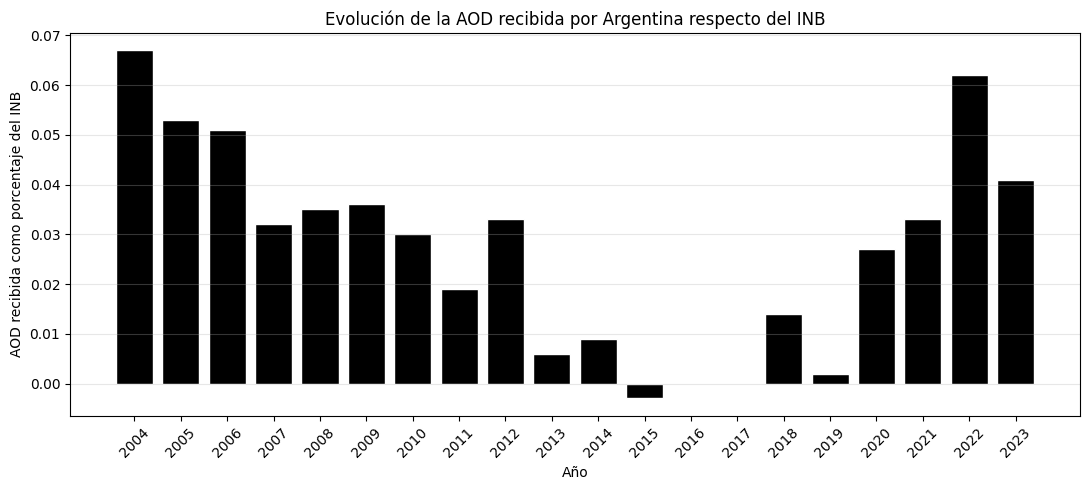

In [ ]:
datos_argentina_ordenados = (
    datos_argentina
    .sort_values("Anio")
)

plt.figure(figsize=(11, 5))

plt.bar(
    datos_argentina_ordenados["Anio"],
    datos_argentina_ordenados["AOD_recibida_porcentaje_INB"],
    color="black",
    edgecolor="white"
)

plt.title("Evolución de la AOD recibida por Argentina respecto del INB")
plt.xlabel("Año")
plt.ylabel("AOD recibida como porcentaje del INB")

plt.xticks(
    datos_argentina_ordenados["Anio"],
    rotation=45
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

En el caso de Argentina, podemos llegar a tres conclusiones. La primera y más evidente, es que en los casos en los que argentina recibió mayores cantidades de dólares, esta tendió a representar un porcentaje mayor dentro de su Ingreso Nacional Bruto. La segunda, aunque no tan fuerte, es que al pasar los años el porcentaje que representaba la ayuda recibida en relación al Ingreso nacional Bruto tendió a disminuir (con una relación de -0.35). La tercera relación observable, aunque más debil (0.23) es que al pasar los años, la ayuda en USD constantes recbida tendió a aumentar. Es decir que, si bien existe una relación positiva entre el pasar d elos años y la ayuda total recibida en USD, esta ayuda tendió a disminuir en lo que refiere al porcentaje que representa dentro del Ingreso Nacional Bruto de Argentina.

Por otro lado, en el gráfico se pobserva como a partir del 2018 hay una tendencia creciente en cuanto al pasar de los años y la ayuda recibida en relación al Ingreso Nacional Bruto, lo que altera la tendencia decreciente que se observa en los años anteriores.

In [ ]:
datos_argentina_hasta_2018 = datos_argentina[
    datos_argentina["Anio"] <= 2018
]

In [ ]:
datos_argentina_hasta_2018[
    [
        "AOD_recibida_USD_constantes_2024",
        "AOD_recibida_porcentaje_INB",
        "Anio"
    ]
].corr().round(2)

,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB,Anio
AOD_recibida_USD_constantes_2024,1.00,0.78,-0.63
AOD_recibida_porcentaje_INB,0.78,1.00,-0.91
Anio,-0.63,-0.91,1.00


Si tomamos solo los años que van desde el 2004 al 2018, vemos como al pasar los años tanto la ayuda recibida en USD constantes como el porcentaje que esta ayuda representa para el INB fue disminuyendo de manera pronunciada, con una relación negativa de 0.63 y 0.91 respectivamente.

### Paso de los años en relación a la ayuda total recibida en USD constantes y en relación a la ayuda respecto al total del INB

In [ ]:
resumen_por_año_ayudaxINB = (     data_ayuda_internacional     .dropna(subset=["AOD_recibida_porcentaje_INB"])     .groupby("Anio")["AOD_recibida_porcentaje_INB"]     .agg(["count", "mean", "median"])     .round(2)     .sort_values("mean", ascending=False) )


In [ ]:
resumen_por_año_ayudaxINB

,count,mean,median
Anio,,,
2020,137,8.35,3.86
2004,146,7.75,3.88
2007,148,7.54,3.20
2008,146,7.30,2.80
2005,148,7.27,3.56
2021,137,7.17,3.25
2011,143,7.04,2.76
2006,148,6.92,3.43
2022,136,6.89,2.51


In [ ]:
año_mayor_ayudaxINB = resumen_por_año_ayudaxINB.index[0]
print (año_mayor_ayudaxINB)

2020


In [ ]:
resumen_por_año_ayudaUSDconstantes2024 = (
    data_ayuda_internacional
    .dropna(subset=["AOD_recibida_USD_constantes_2024"])
    .groupby("Anio")["AOD_recibida_USD_constantes_2024"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("mean", ascending=False)
)


In [ ]:
resumen_por_año_ayudaUSDconstantes2024

,count,mean,median
Anio,,,
2023,136,1.273963e+09,486606810.0
2022,136,1.196013e+09,494657365.0
2020,137,1.107821e+09,533401380.0
2021,137,1.044678e+09,517333250.0
2018,138,9.242097e+08,420056640.0
2017,141,9.124581e+08,337559940.0
2019,138,9.084688e+08,443326480.0
2016,141,8.817249e+08,363436060.0
2015,141,8.237269e+08,390685470.0


In [ ]:
año_mayor_ayuda_total_USDconstantes =resumen_por_año_ayudaUSDconstantes2024.index[0]
print (año_mayor_ayuda_total_USDconstantes)

2023


In [ ]:
datos_por_año = pd.DataFrame({
    "AOD_recibida_USD_constantes_2024":
        resumen_por_año_ayudaUSDconstantes2024["mean"],

    "AOD_recibida_porcentaje_INB":
        resumen_por_año_ayudaxINB["mean"]
}).reset_index()

datos_por_año

,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
0,2004,5.181382e+08,7.75
1,2005,7.337033e+08,7.27
2,2006,6.796538e+08,6.92
3,2007,6.161580e+08,7.54
4,2008,6.632794e+08,7.30
5,2009,6.785528e+08,6.87
6,2010,6.138756e+08,6.32
7,2011,7.105364e+08,7.04
8,2012,7.114829e+08,6.24
9,2013,7.756441e+08,6.27


In [ ]:
datos_por_año[
    [
        "AOD_recibida_USD_constantes_2024",
        "AOD_recibida_porcentaje_INB",
        "Anio"
    ]
].corr().round(2)

,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB,Anio
AOD_recibida_USD_constantes_2024,1.00,-0.03,0.93
AOD_recibida_porcentaje_INB,-0.03,1.00,-0.24
Anio,0.93,-0.24,1.00


In [ ]:
import seaborn as sns

In [ ]:
matriz_correlacion = datos_por_año[
    [
        "AOD_recibida_USD_constantes_2024",
        "AOD_recibida_porcentaje_INB",
        "Anio"
    ]
].corr()

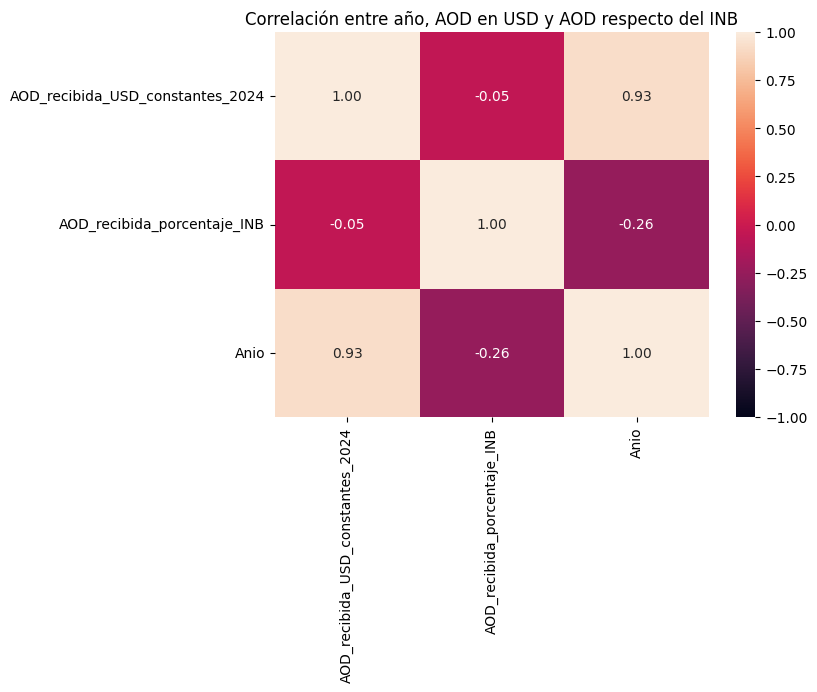

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlación entre año, AOD en USD y AOD respecto del INB")

plt.show()

Dentro de los años analizados, aquel en el que la ayuda internacional representó un mayor ingreso en relación al Ingreso Nacional Bruto de los distintos países fue 2020, con un promedio de 8.35, lo que cobra sentido si analizamos el contexto pandemico de la época. Sin embargo, si analizamos la ayuda internacional recibida en términos totales, se observa que 2023 fue el año que presentó una suma total mayor. Este último dato se relaciona con que al pasar los años la suma total de dinero en USD constantes para 2024 recibido por los países fue aumentando con los años, presentando ambas variables una relación positiva de 0.93. Sin embargo, el porcentaje que esto representó en el Ingreso Nacional Bruto en promedio según cada año tendió a disminuir.

#Análisis variables cualitativas

##Análisis univariado

### Países

In [ ]:
frecuencia_paises = (
    data_ayuda_internacional["Pais"]
    .value_counts()
)

In [ ]:
frecuencia_paises

,count
Pais,
Afghanistan,20
Albania,20
Algeria,20
Angola,20
Argentina,20
...,...
Croatia,7
Oman,7
Saudi Arabia,4


In [ ]:
frecuencia_paises.tail(30)

,count
Pais,
Syria,20
Tajikistan,20
Togo,20
South Africa,20
Suriname,20
Sudan,20
Tanzania,20
Thailand,20
Turkey,20


Teniendo en cuenta que el análisis abarca el período de 2004 a 2023 (20 años), y no hay filas duplicadas, debería haber un registro por año de cada país analizado, es decir, 20 registros por país. Esta condición se cumple en la mayoría de los casos, exceptuando a Bielorrusia, Libia y Ucrania, que cuentan con 19 registros; Antigua y Barbuda, con 18; Islas Cook, con 16; Chile, Uruguay y Seychelles, con 14; Sudán del Sur, con 13; Anguila y San Cristóbal y Nieves, con 10; Trinidad y Tobago, Barbados, Mayotte, Croacia y Omán, con 7; Arabia Saudita e Islas Turcas y Caicos, con 4; y Baréin, que presenta únicamente 1 registro durante el período analizado.


Por otro lado, es necesario tener en cuenta que este data_set no cuenta con datos de todos los países. Esto se observa al dividir la cantidad de filas (2930) por la cantidad de años (20), lo que nos da un total de 146,5. Sin embargo, este cálculo está afectado por los países que no cuentan con información para los 20 años completos. Como se señaló anteriormente, entre los 19 países con registros incompletos faltan en total 170 observaciones, las cuales corresponden a otros países. Con esta cantidad de observaciones faltantes en algunos países, podemos calcular que 170/20= 8,5, sumado a los 146,5 nos da un total de 155 países. Por lo tanto, teniendo en cuenta que en el mundo hay 195 países reconocidos de manera oficial, debemos tomar precausiones en cuanto a algunas conclusiones que puedan generarse.

En el caso de este data set, la ausencia de muchos países europeos se debe a la característica analizada, la cuál es la ayuda internacional recibida. Por lo tanto, al centrarse el data set principalmente en receptores de ayuda internacional, muchos de estos países se encuentran ausentes al ser donantes de esta ayuda.

### Grupos por ingreso

In [ ]:
frecuencia_grupo_ingreso = (
    data_ayuda_internacional["Grupo_ingreso"]
    .value_counts()
)

In [ ]:
frecuencia_grupo_ingreso

,count
Grupo_ingreso,
Lower-middle-income countries,1037
Upper-middle-income countries,919
Low-income countries,733
High-income countries,87
Sin clasificar,74


In [ ]:
proporción_grupo_ingreso = data_ayuda_internacional[
    "Grupo_ingreso"
].value_counts(normalize=True)

In [ ]:
proporción_grupo_ingreso

,proportion
Grupo_ingreso,
Lower-middle-income countries,0.363860
Upper-middle-income countries,0.322456
Low-income countries,0.257193
High-income countries,0.030526
Sin clasificar,0.025965


In [ ]:
tabla_grupo_ingreso = pd.DataFrame({
    "Frecuencia": frecuencia_grupo_ingreso,
    "Proporcion": proporción_grupo_ingreso,
    "Porcentaje": (proporción_grupo_ingreso * 100).round(2)
})

In [ ]:
tabla_grupo_ingreso

,Frecuencia,Proporcion,Porcentaje
Grupo_ingreso,,,
Lower-middle-income countries,1037,0.363860,36.39
Upper-middle-income countries,919,0.322456,32.25
Low-income countries,733,0.257193,25.72
High-income countries,87,0.030526,3.05
Sin clasificar,74,0.025965,2.60


In [ ]:
print("\nModa:", data_ayuda_internacional["Grupo_ingreso"].mode()[0])


Moda: Lower-middle-income countries


In [ ]:
import matplotlib.pyplot as plt


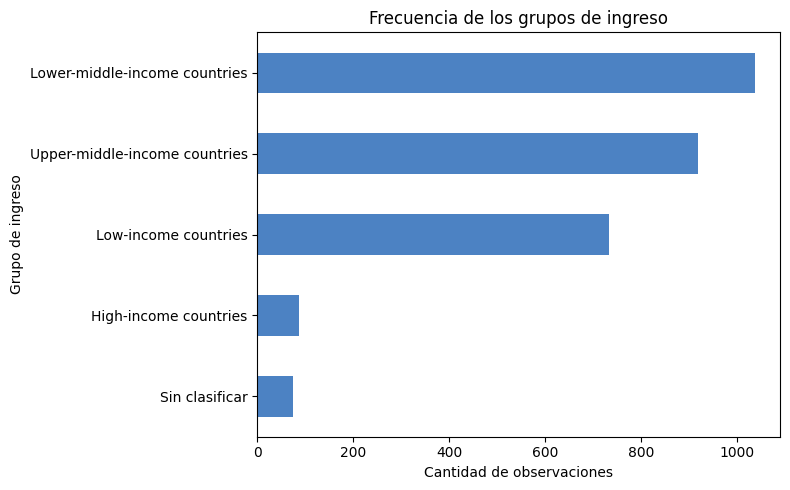

In [ ]:
frecuencia_grupo_ingreso.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    color="#4C82C3"
)

plt.title("Frecuencia de los grupos de ingreso")
plt.xlabel("Cantidad de observaciones")
plt.ylabel("Grupo de ingreso")

plt.tight_layout()
plt.show()

Habiendo analizado la variable cualitativa "Grupo_ingreso", puede observarse que la mayoria de las observaciones (1037, que representa el 36% del total) se concentran en la categoría de países con ingresos medio-bajos. Por su parte, los países de ingresos medio-altos presentan aproximadamente un tercio (32%) del total de las observaciones, seguidas por los países de ingresos bajos, que presentan un 25% sobre el total de observaciones. Por su parte, se observa que la mínoria de las observaciones, solo 87, es decir el 3%, responden a países de ingresos altos. Finalmente el 2,5% de las observaciones no cuentan con datos sobre que grupo forman parte.

##Análisis bivariado

In [ ]:
frecuencia_región_mundial = (
    data_ayuda_internacional["Region_mundial"]
    .value_counts()
)

In [ ]:
frecuencia_región_mundial

,count
Region_mundial,
Africa,1073
Asia,732
North America,396
Oceania,256
South America,228
Europe,165


In [ ]:
tabla_contingencia = pd.crosstab(
    data_ayuda_internacional["Region_mundial"],
    data_ayuda_internacional["Grupo_ingreso"],
    normalize="index"
).round(2)

In [ ]:
tabla_contingencia

Grupo_ingreso,High-income countries,Low-income countries,Lower-middle-income countries,Sin clasificar,Upper-middle-income countries
Region_mundial,,,,,
Africa,0.01,0.51,0.32,0.00,0.15
Asia,0.01,0.22,0.49,0.00,0.28
Europe,0.02,0.01,0.30,0.02,0.65
North America,0.08,0.04,0.22,0.09,0.56
Oceania,0.05,0.04,0.51,0.12,0.28
South America,0.07,0.00,0.26,0.02,0.64


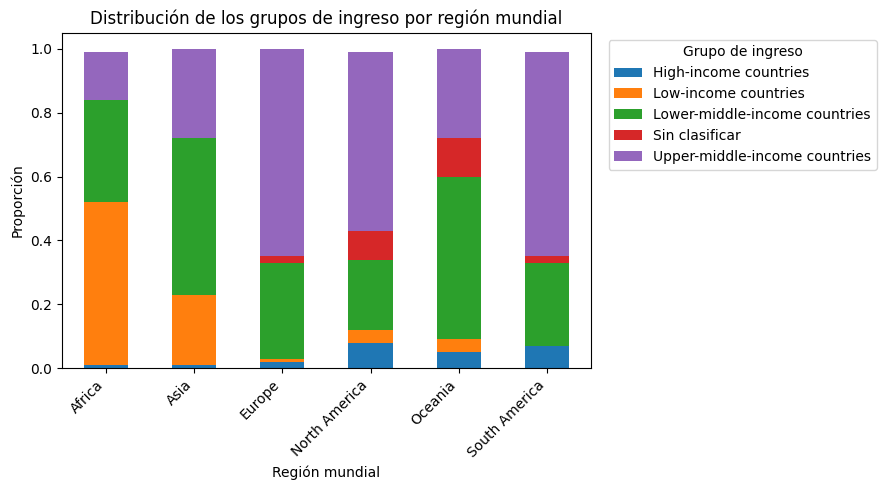

In [ ]:
tabla_contingencia.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Distribución de los grupos de ingreso por región mundial")
plt.xlabel("Región mundial")
plt.ylabel("Proporción")
plt.legend(
    title="Grupo de ingreso",
    bbox_to_anchor=(1.02, 1)
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Al analizar la presencia de los distintos grupos de ingreso dentro de cada región particular, se observan diferencias claras en la composición económica de cada una.

En primer lugar, África, región que, como se verá a continuación en el análisis, es la que mayor ayuda en términos totales en el período analizado recibió, se compone principalmente de observaciones que corresponden a países de ingreso bajo y medio-bajo. Similar a esta región, Asia concentra muchas observaciones de países con ingresos bajos y mayormente medio-bajos.

Por su parte, Oceanía se compone por mitad de observaciones de países de ingresos medio-bajos, correspondiente al 51% del total de la región, siendo la región que mayor concentración de este grupo de ingreso tiene.

Por último, se observa que tanto América del Sur, América del Norte y Europa  presentan una mayor proporción de observaciones correspondientes a ingresos medio-altos, superando este grupo de ingresos más de la mitad de las observaciones de cada región.

# Análisis combinado variables cuantitativas y cualitativas

### Datos 2023

In [ ]:
datos_2023 = data_ayuda_internacional[
    data_ayuda_internacional["Anio"] == 2023
].dropna(
    subset=["AOD_recibida_porcentaje_INB"]
)

In [ ]:
datos_2023

,ID_observacion,Codigo_pais,Pais,Region_mundial,Grupo_ingreso,Anio,AOD_recibida_USD_constantes_2024,AOD_recibida_porcentaje_INB
19,AFG-2023,AFG,Afghanistan,Asia,Low-income countries,2023,3.129451e+09,17.746
39,ALB-2023,ALB,Albania,Europe,Upper-middle-income countries,2023,3.728472e+08,1.551
59,DZA-2023,DZA,Algeria,Africa,Upper-middle-income countries,2023,2.075523e+08,0.083
79,AGO-2023,AGO,Angola,Africa,Lower-middle-income countries,2023,1.504850e+08,0.192
127,ARG-2023,ARG,Argentina,South America,Upper-middle-income countries,2023,2.681626e+08,0.041
...,...,...,...,...,...,...,...,...
2829,VEN-2023,VEN,Venezuela,South America,NaN,2023,4.147870e+08,0.340
2849,VNM-2023,VNM,Vietnam,Asia,Lower-middle-income countries,2023,8.395149e+08,0.202
2889,YEM-2023,YEM,Yemen,Asia,Low-income countries,2023,4.247657e+09,47.302
2909,ZMB-2023,ZMB,Zambia,Africa,Lower-middle-income countries,2023,1.641598e+09,6.100


In [ ]:
ranking_2023 = (
    datos_2023[
        ["Pais", "AOD_recibida_porcentaje_INB"]
    ]
    .sort_values(
        "AOD_recibida_porcentaje_INB",
        ascending=False
    )
)

In [ ]:
ranking_2023

,Pais,AOD_recibida_porcentaje_INB
2716,Tuvalu,81.358
2505,Syria,47.832
2889,Yemen,47.302
2425,South Sudan,41.144
1570,Marshall Islands,40.687
...,...,...
354,Brazil,0.033
1637,Mexico,0.026
2565,Thailand,0.017
1510,Malaysia,0.002


In [ ]:
ranking_2023.head(20)

,Pais,AOD_recibida_porcentaje_INB
2716,Tuvalu,81.358
2505,Syria,47.832
2889,Yemen,47.302
2425,South Sudan,41.144
1570,Marshall Islands,40.687
474,Central African Republic,27.533
1657,Micronesia (country),25.780
394,Burundi,24.397
2625,Tonga,23.384
2755,Ukraine,20.900


Durante 2023, el país que mayor ayuda económica internacional en relación con su Ingreso Nacional Bruto recibió fue Tuvalu. Esto cobra sentido al analizar la coyuntura del país, ya que contiene una población y por lo tanto un economía muy pequeña, la cual escasea recursos además de estar amenazada por la suba del nivel del mar.

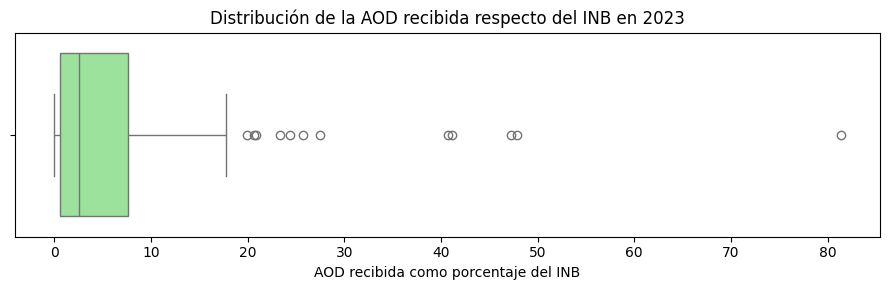

In [ ]:

plt.figure(figsize=(9, 3))

sns.boxplot(
    data=ranking_2023,
    x="AOD_recibida_porcentaje_INB",
    color="lightgreen"
)

plt.title("Distribución de la AOD recibida respecto del INB en 2023")
plt.xlabel("AOD recibida como porcentaje del INB")
plt.tight_layout()
plt.show()

ESte boxplot nos muestra un paneo general de como se distribuyó en 2023 el porcentaje que representó sobre el Ingreso Nacional Bruto la ayuda internacional para cada país.

Se observa que 50% central de los países tuvo valores entre el 1% y el 8%. La mediana se ubica alrededor del 2%, y el tercer cuartil en 18%. A partir de allí aparecen un poco más de una decena valores atípicos, correspondientes a países donde la ayuda tuvo un peso excepcionalmente alto sobre su economía, con casos

In [ ]:
resumen_por_región_mundial = (
    data_ayuda_internacional
    .groupby("Region_mundial")["AOD_recibida_USD_constantes_2024"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .sort_values("median", ascending=False)
)

### Análisis ayuda total recibida por región mundial

In [ ]:
resumen_por_región_mundial

,count,mean,median,std
Region_mundial,,,,
Africa,1073,9.939628e+08,643623040.0,1.134393e+09
Asia,732,1.245696e+09,478473335.0,2.140056e+09
Europe,165,8.997482e+08,361035650.0,3.903400e+09
South America,228,3.631807e+08,172062095.0,4.159178e+08
Oceania,256,1.355469e+08,78926100.0,1.748973e+08
North America,396,2.484577e+08,75749100.0,3.849320e+08


In [ ]:
ayuda_total_por_region = (
    data_ayuda_internacional
    .groupby("Region_mundial")[
        "AOD_recibida_USD_constantes_2024"
    ]
    .sum()
    .sort_values(ascending=False)
)

In [ ]:
ayuda_total_por_region

,AOD_recibida_USD_constantes_2024
Region_mundial,
Africa,1.068063e+12
Asia,9.118497e+11
Europe,1.484585e+11
North America,9.838926e+10
South America,8.280519e+10
Oceania,3.770807e+10


Podemos observar que durante todo el período analizado (de 2004 a 2023), la región mundial que mayor ayuda económica total en USD recibió fue África. A su vez esta región presenta casos que tiran la media hacia arriba, es decir que recibieron mucha ayuda económica en comparación a la mayoría de los casos, ya que se presenta una mediana de 6.26 y una media de 9.77

# Conclusión
El análisis, que responde a las preguntas planteadas, muestra que África fue la región que recibió el mayor monto total de AOD entre 2004 y 2023. Aa su vez, en 2023, Tuvalu fue el país donde la ayuda tuvo mayor peso relativo, al representar el 81,36 % de su INB. Por último, 2020 registró el promedio más alto de AOD respecto del INB (8,35 %), mientras que 2023 concentró el mayor monto total, dentro de una tendencia general creciente.